# 07 — Optical Tweezer Scaling v2

**Primary specification:** array scale specifies control constraints.

Notebook 07 develops the first computation branch of `scalable-platforms`: large optical tweezer arrays for neutral-atom computation. It connects array size, filling fraction, rearrangement, coherent transport, control overhead, and error-correction pathways.

The v2 refinement keeps the quantitative scaling plots and replaces the earlier summary/constraint diagrams with an engineering pipeline and coherence-budget figure.


## 1. Start here

Notebook 00 established the repository-level statement:

> **Coherence specifies scalable platforms.**

Notebook 07 specializes that statement to optical tweezer arrays:

\[
\text{array scale}
\rightarrow
\text{many neutral atoms}
\rightarrow
\text{filling + rearrangement}
\rightarrow
\text{coherent transport}
\rightarrow
\text{control overhead}
\rightarrow
\text{error-correction pathways}
\]

The central shift is:

> **Scaling an array means scaling control, not only increasing atom count.**


In [40]:
from pathlib import Path
import json
import zipfile

import matplotlib.pyplot as plt
import pandas as pd

NOTEBOOK_NAME = "07_optical_tweezer_scaling"
CWD = Path.cwd().resolve()

if (CWD / "notebooks").exists() or (CWD / "figures").exists():
    REPO_ROOT = CWD
elif CWD.name == "notebooks":
    REPO_ROOT = CWD.parent
else:
    REPO_ROOT = CWD

NOTEBOOKS = REPO_ROOT / "notebooks"
FIGURES = REPO_ROOT / "figures"
RESULTS = REPO_ROOT / "results" / NOTEBOOK_NAME
RESULT_FIGURES = RESULTS / "figures"

for path in [NOTEBOOKS, FIGURES, RESULTS, RESULT_FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

def save_png(fig, name, dpi=220):
    repo_path = FIGURES / f"{name}.png"
    result_path = RESULT_FIGURES / f"{name}.png"
    fig.savefig(repo_path, dpi=dpi, bbox_inches="tight")
    fig.savefig(result_path, dpi=dpi, bbox_inches="tight")
    print(f"✓ Saved {repo_path}")
    print(f"✓ Saved {result_path}")
    return repo_path

print(f"Repo root: {REPO_ROOT}")
print(f"Figures:   {FIGURES}")
print(f"Results:   {RESULTS}")


Repo root: /content
Figures:   /content/figures
Results:   /content/results/07_optical_tweezer_scaling


## 2. Scaling variables

\[
N_{\mathrm{atoms}} = f N_{\mathrm{sites}}
\]

\[
R_{\mathrm{control}}
=
\frac{N_{\mathrm{move}}T_{\mathrm{move}}}{T_{\mathrm{coh}}}
\]


In [41]:
scaling_variables = pd.DataFrame([
    {"symbol": "N_sites", "meaning": "available optical tweezer sites", "role": "array scale"},
    {"symbol": "N_atoms", "meaning": "trapped neutral atoms", "role": "available qubits"},
    {"symbol": "f", "meaning": "filling fraction", "role": "site occupancy"},
    {"symbol": "N_move", "meaning": "atoms moved during rearrangement", "role": "transport workload"},
    {"symbol": "T_move", "meaning": "time per move operation", "role": "transport latency"},
    {"symbol": "T_coh", "meaning": "useful coherence time", "role": "coherence budget"},
    {"symbol": "R_control", "meaning": "control overhead", "role": "scaling constraint"},
])
variables_path = RESULTS / "scaling_variables.csv"
scaling_variables.to_csv(variables_path, index=False)
scaling_variables


,symbol,meaning,role
0,N_sites,available optical tweezer sites,array scale
1,N_atoms,trapped neutral atoms,available qubits
2,f,filling fraction,site occupancy
3,N_move,atoms moved during rearrangement,transport workload
4,T_move,time per move operation,transport latency
5,T_coh,useful coherence time,coherence budget
6,R_control,control overhead,scaling constraint


## 3. Hero statement


✓ Saved /content/figures/07_hero_statement.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_hero_statement.png


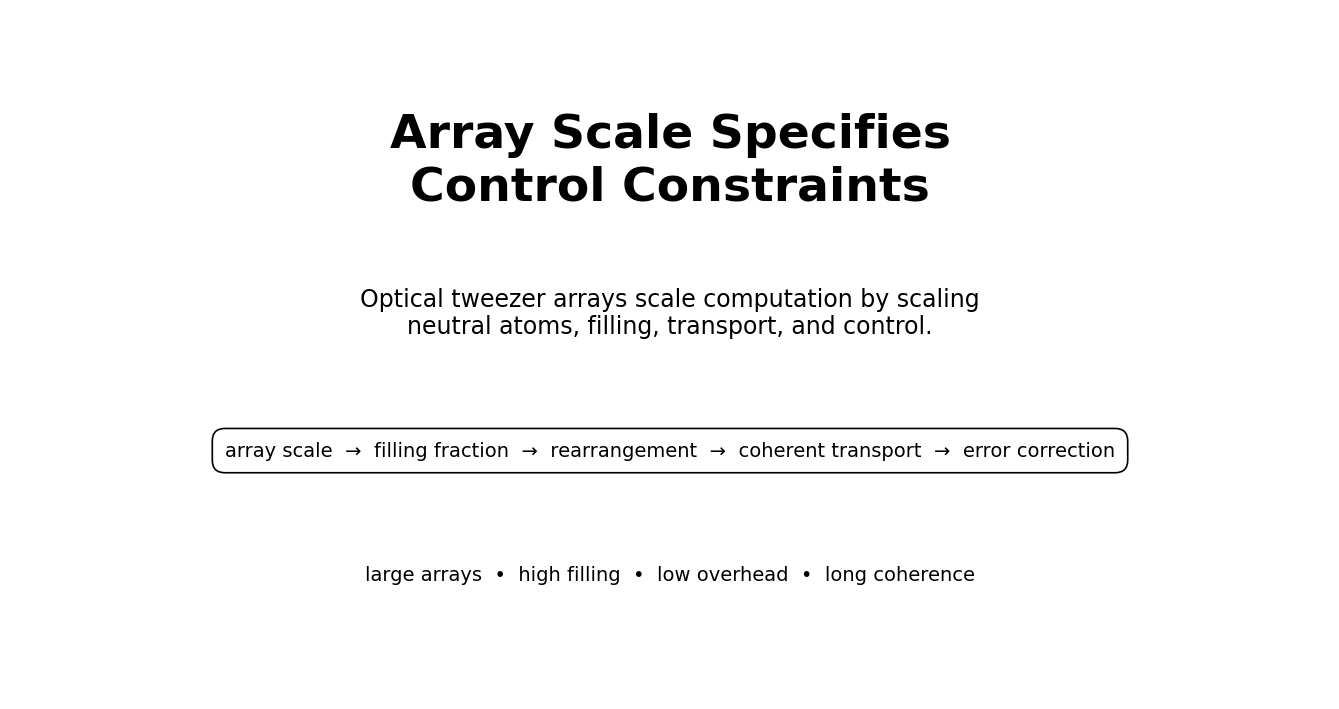

PosixPath('/content/figures/07_hero_statement.png')

In [42]:
fig, ax = plt.subplots(figsize=(13.5, 7.2))
ax.axis("off")

ax.text(0.5, 0.78, "Array Scale Specifies\nControl Constraints",
        ha="center", va="center", fontsize=34, weight="bold")
ax.text(0.5, 0.56,
        "Optical tweezer arrays scale computation by scaling\nneutral atoms, filling, transport, and control.",
        ha="center", va="center", fontsize=17)
ax.text(0.5, 0.36,
        "array scale  →  filling fraction  →  rearrangement  →  coherent transport  →  error correction",
        ha="center", va="center", fontsize=14,
        bbox=dict(boxstyle="round,pad=0.65", linewidth=1.2, facecolor="white"))
ax.text(0.5, 0.18,
        "large arrays  •  high filling  •  low overhead  •  long coherence",
        ha="center", va="center", fontsize=14)

fig.tight_layout()
hero_fig = save_png(fig, "07_hero_statement")
plt.show()
hero_fig


## 4. Optical tweezer scaling chain


✓ Saved /content/figures/07_array_scaling_chain.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_array_scaling_chain.png


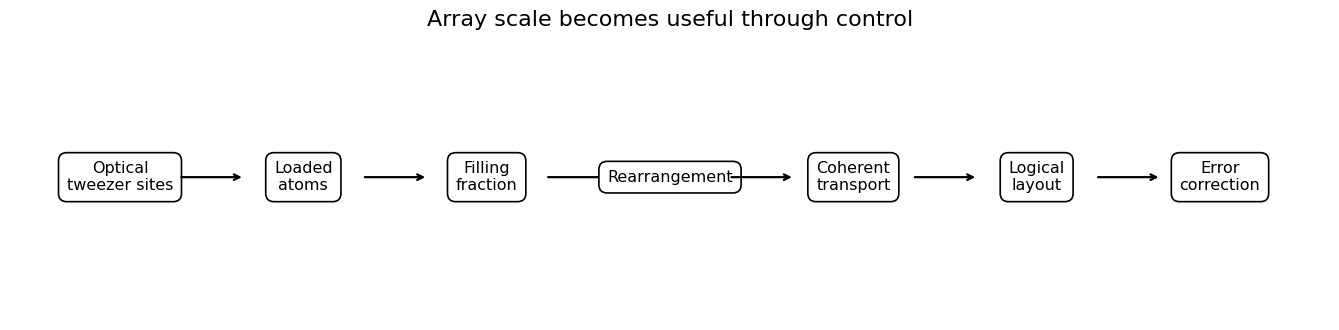

PosixPath('/content/figures/07_array_scaling_chain.png')

In [43]:
chain_steps = [
    "Optical\ntweezer sites",
    "Loaded\natoms",
    "Filling\nfraction",
    "Rearrangement",
    "Coherent\ntransport",
    "Logical\nlayout",
    "Error\ncorrection",
]

fig, ax = plt.subplots(figsize=(13.5, 3.4))
ax.axis("off")
y = 0.5

for i, label in enumerate(chain_steps):
    ax.text(i, y, label, ha="center", va="center", fontsize=11.5,
            bbox=dict(boxstyle="round,pad=0.52", linewidth=1.2, facecolor="white"))
    if i < len(chain_steps) - 1:
        ax.annotate("", xy=(i + 0.68, y), xytext=(i + 0.32, y),
                    arrowprops=dict(arrowstyle="->", linewidth=1.6))

ax.set_xlim(-0.6, len(chain_steps) - 0.4)
ax.set_ylim(0, 1)
ax.set_title("Array scale becomes useful through control", fontsize=16)
fig.tight_layout()

chain_fig = save_png(fig, "07_array_scaling_chain")
plt.show()
chain_fig


## 5. Capacity from filling fraction


✓ Saved /content/figures/07_tweezer_capacity.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_tweezer_capacity.png


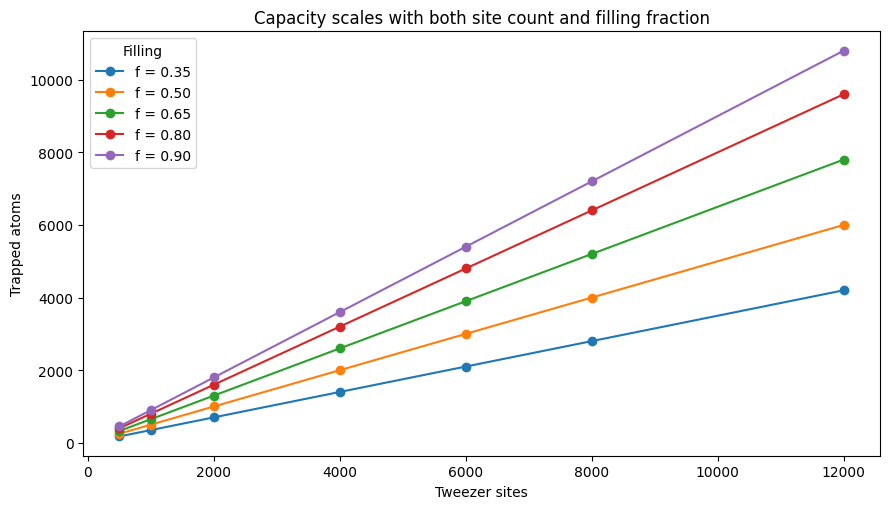

,N_sites,filling_fraction,N_atoms
0,500,0.35,175.0
1,500,0.50,250.0
2,500,0.65,325.0
3,500,0.80,400.0
4,500,0.90,450.0


In [44]:
site_counts = [500, 1000, 2000, 4000, 6000, 8000, 12000]
fillings = [0.35, 0.50, 0.65, 0.80, 0.90]

capacity_rows = []
for n in site_counts:
    for f in fillings:
        capacity_rows.append({"N_sites": n, "filling_fraction": f, "N_atoms": f * n})

capacity = pd.DataFrame(capacity_rows)
capacity_path = RESULTS / "tweezer_capacity.csv"
capacity.to_csv(capacity_path, index=False)

fig, ax = plt.subplots(figsize=(9, 5.2))
for f in fillings:
    sub = capacity[capacity["filling_fraction"] == f]
    ax.plot(sub["N_sites"], sub["N_atoms"], marker="o", label=f"f = {f:.2f}")
ax.set_xlabel("Tweezer sites")
ax.set_ylabel("Trapped atoms")
ax.set_title("Capacity scales with both site count and filling fraction")
ax.legend(title="Filling")
fig.tight_layout()

capacity_fig = save_png(fig, "07_tweezer_capacity")
plt.show()
capacity.head()


## 6. Filling fraction as an engineering lever


✓ Saved /content/figures/07_filling_fraction.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_filling_fraction.png


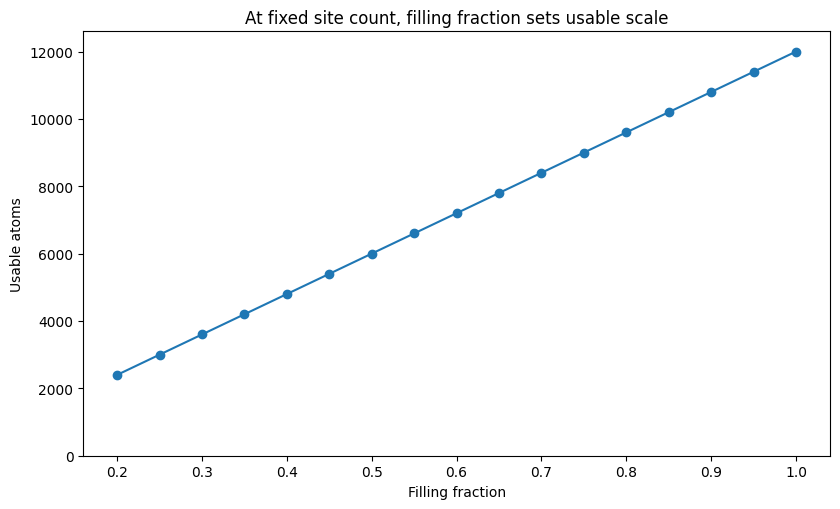

,filling_fraction,N_atoms
0,0.20,2400.0
1,0.25,3000.0
2,0.30,3600.0
3,0.35,4200.0
4,0.40,4800.0


In [45]:
fixed_sites = 12000
fill_grid = [i / 100 for i in range(20, 101, 5)]
filling_curve = pd.DataFrame({
    "filling_fraction": fill_grid,
    "N_atoms": [fixed_sites * f for f in fill_grid],
})
filling_path = RESULTS / "filling_fraction_curve.csv"
filling_curve.to_csv(filling_path, index=False)

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.plot(filling_curve["filling_fraction"], filling_curve["N_atoms"], marker="o")
ax.set_xlabel("Filling fraction")
ax.set_ylabel("Usable atoms")
ax.set_title("At fixed site count, filling fraction sets usable scale")
ax.set_ylim(0, fixed_sites * 1.05)
fig.tight_layout()

filling_fig = save_png(fig, "07_filling_fraction")
plt.show()
filling_curve.head()


## 7. Transport overhead


✓ Saved /content/figures/07_transport_overhead.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_transport_overhead.png


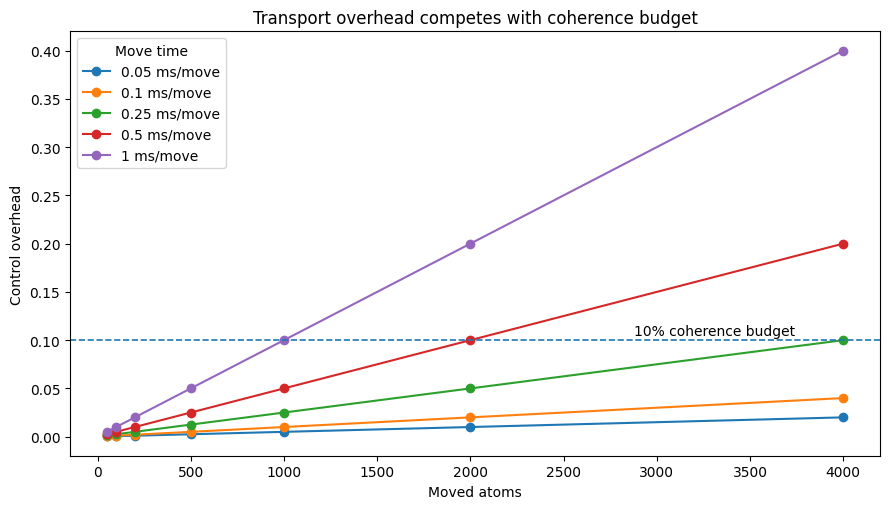

,N_move,T_move_ms,T_coh_s,R_control
0,50,0.05,10.0,0.00025
1,50,0.10,10.0,0.00050
2,50,0.25,10.0,0.00125
3,50,0.50,10.0,0.00250
4,50,1.00,10.0,0.00500


In [46]:
T_coh = 10.0
move_counts = [50, 100, 200, 500, 1000, 2000, 4000]
move_times_ms = [0.05, 0.10, 0.25, 0.50, 1.00]

overhead_rows = []
for nmove in move_counts:
    for t_ms in move_times_ms:
        overhead_rows.append({
            "N_move": nmove,
            "T_move_ms": t_ms,
            "T_coh_s": T_coh,
            "R_control": nmove * (t_ms / 1000.0) / T_coh,
        })

overhead = pd.DataFrame(overhead_rows)
overhead_path = RESULTS / "transport_overhead.csv"
overhead.to_csv(overhead_path, index=False)

fig, ax = plt.subplots(figsize=(9, 5.2))
for t_ms in move_times_ms:
    sub = overhead[overhead["T_move_ms"] == t_ms]
    ax.plot(sub["N_move"], sub["R_control"], marker="o", label=f"{t_ms:g} ms/move")

ax.axhline(0.1, linestyle="--", linewidth=1.2)
ax.text(max(move_counts) * 0.72, 0.105, "10% coherence budget", fontsize=10)
ax.set_xlabel("Moved atoms")
ax.set_ylabel("Control overhead")
ax.set_title("Transport overhead competes with coherence budget")
ax.legend(title="Move time")
fig.tight_layout()

overhead_fig = save_png(fig, "07_transport_overhead")
plt.show()
overhead.head()


## 8. Engineering pipeline


✓ Saved /content/figures/07_scaling_constraints_v2.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_scaling_constraints_v2.png


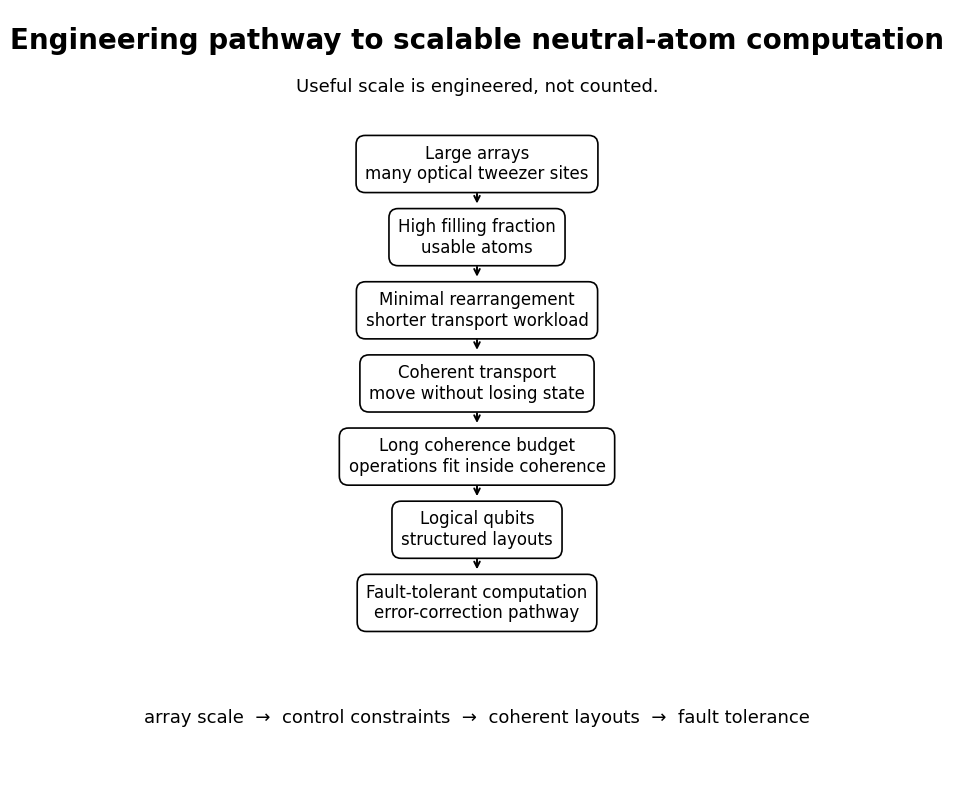

PosixPath('/content/figures/07_scaling_constraints_v2.png')

In [47]:
pipeline = [
    ("Large arrays", "many optical tweezer sites"),
    ("High filling fraction", "usable atoms"),
    ("Minimal rearrangement", "shorter transport workload"),
    ("Coherent transport", "move without losing state"),
    ("Long coherence budget", "operations fit inside coherence"),
    ("Logical qubits", "structured layouts"),
    ("Fault-tolerant computation", "error-correction pathway"),
]

fig, ax = plt.subplots(figsize=(10.5, 8.0))
ax.axis("off")
ax.text(0.5, 0.96, "Engineering pathway to scalable neutral-atom computation", ha="center", va="center", fontsize=20, weight="bold")
ax.text(0.5, 0.90, "Useful scale is engineered, not counted.", ha="center", va="center", fontsize=13)

x = 0.5
y0 = 0.80
dy = 0.095

for i, (title, subtitle) in enumerate(pipeline):
    y = y0 - i * dy
    ax.text(x, y, f"{title}\n{subtitle}", ha="center", va="center", fontsize=12,
            bbox=dict(boxstyle="round,pad=0.55", linewidth=1.2, facecolor="white"))
    if i < len(pipeline) - 1:
        ax.annotate("", xy=(x, y - 0.055), xytext=(x, y - 0.035),
                    arrowprops=dict(arrowstyle="->", linewidth=1.4))

ax.text(0.5, 0.08,
        "array scale  →  control constraints  →  coherent layouts  →  fault tolerance",
        ha="center", va="center", fontsize=13)

fig.tight_layout()
pipeline_fig = save_png(fig, "07_scaling_constraints_v2")
plt.show()
pipeline_fig


## 9. Engineering budget


✓ Saved /content/figures/07_engineering_budget.png
✓ Saved /content/results/07_optical_tweezer_scaling/figures/07_engineering_budget.png


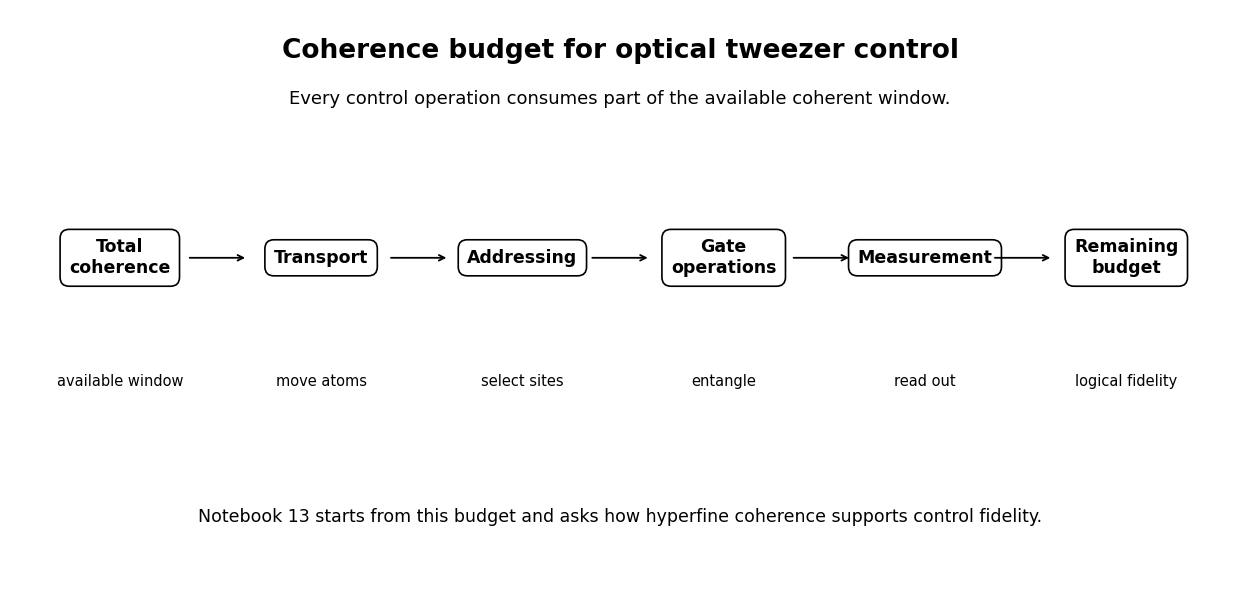

,stage,role
0,Total coherence,available coherent window
1,Transport,rearrangement and long-distance motion
2,Addressing,site-selective control and crosstalk
3,Gate operations,entangling and logical operations
4,Measurement,readout and verification
5,Remaining budget,margin for logical fidelity


In [48]:
budget_rows = [
    {"stage": "Total coherence", "role": "available coherent window"},
    {"stage": "Transport", "role": "rearrangement and long-distance motion"},
    {"stage": "Addressing", "role": "site-selective control and crosstalk"},
    {"stage": "Gate operations", "role": "entangling and logical operations"},
    {"stage": "Measurement", "role": "readout and verification"},
    {"stage": "Remaining budget", "role": "margin for logical fidelity"},
]
budget = pd.DataFrame(budget_rows)
budget_path = RESULTS / "coherence_budget.csv"
budget.to_csv(budget_path, index=False)

budget_steps = [
    ("Total\ncoherence", "available window"),
    ("Transport", "move atoms"),
    ("Addressing", "select sites"),
    ("Gate\noperations", "entangle"),
    ("Measurement", "read out"),
    ("Remaining\nbudget", "logical fidelity"),
]

fig, ax = plt.subplots(figsize=(12.5, 6.2))
ax.axis("off")
ax.text(0.5, 0.93, "Coherence budget for optical tweezer control", ha="center", va="center", fontsize=19, weight="bold")
ax.text(0.5, 0.85, "Every control operation consumes part of the available coherent window.", ha="center", va="center", fontsize=13)

for i, (title, subtitle) in enumerate(budget_steps):
    x = 0.09 + i * 0.165
    ax.text(x, 0.58, title, ha="center", va="center", fontsize=12.5, weight="bold",
            bbox=dict(boxstyle="round,pad=0.52", linewidth=1.2, facecolor="white"))
    ax.text(x, 0.37, subtitle, ha="center", va="center", fontsize=10.5)
    if i < len(budget_steps) - 1:
        ax.annotate("", xy=(x + 0.105, 0.58), xytext=(x + 0.055, 0.58),
                    arrowprops=dict(arrowstyle="->", linewidth=1.3))

ax.text(0.5, 0.14,
        "Notebook 13 starts from this budget and asks how hyperfine coherence supports control fidelity.",
        ha="center", va="center", fontsize=12.5)

fig.tight_layout()
budget_fig = save_png(fig, "07_engineering_budget")
plt.show()
budget


## 10. Notebook summary


In [49]:
summary = pd.DataFrame([
    {"layer": "array scale", "specification": "more sites expand possible layouts"},
    {"layer": "filling fraction", "specification": "site occupancy controls usable atom count"},
    {"layer": "rearrangement", "specification": "sorting converts random loading into useful layouts"},
    {"layer": "transport", "specification": "movement must preserve state information"},
    {"layer": "control overhead", "specification": "transport must fit inside the coherence budget"},
    {"layer": "error correction", "specification": "useful scale points toward logical layouts"},
])
summary_path = RESULTS / "notebook_07_summary.csv"
summary.to_csv(summary_path, index=False)
summary


,layer,specification
0,array scale,more sites expand possible layouts
1,filling fraction,site occupancy controls usable atom count
2,rearrangement,sorting converts random loading into useful la...
3,transport,movement must preserve state information
4,control overhead,transport must fit inside the coherence budget
5,error correction,useful scale points toward logical layouts


## 11. Save notebook manifest


In [50]:
notebook_manifest = {
    "notebook": "07_optical_tweezer_scaling.ipynb",
    "title": "Optical Tweezer Scaling",
    "primary_specification": "array scale specifies control constraints",
    "statement": "Scaling an array means scaling control, not only increasing atom count.",
    "outputs": {
        "scaling_variables": str(variables_path.relative_to(REPO_ROOT)),
        "capacity_csv": str(capacity_path.relative_to(REPO_ROOT)),
        "filling_csv": str(filling_path.relative_to(REPO_ROOT)),
        "overhead_csv": str(overhead_path.relative_to(REPO_ROOT)),
        "budget_csv": str(budget_path.relative_to(REPO_ROOT)),
        "summary_csv": str(summary_path.relative_to(REPO_ROOT)),
        "hero_figure": str(hero_fig.relative_to(REPO_ROOT)),
        "chain_figure": str(chain_fig.relative_to(REPO_ROOT)),
        "capacity_figure": str(capacity_fig.relative_to(REPO_ROOT)),
        "filling_figure": str(filling_fig.relative_to(REPO_ROOT)),
        "overhead_figure": str(overhead_fig.relative_to(REPO_ROOT)),
        "pipeline_figure": str(pipeline_fig.relative_to(REPO_ROOT)),
        "budget_figure": str(budget_fig.relative_to(REPO_ROOT)),
    },
}
manifest_path = RESULTS / "07_optical_tweezer_scaling_manifest.json"
manifest_path.write_text(json.dumps(notebook_manifest, indent=2), encoding="utf-8")
notebook_manifest


{'notebook': '07_optical_tweezer_scaling.ipynb',
 'title': 'Optical Tweezer Scaling',
 'primary_specification': 'array scale specifies control constraints',
 'statement': 'Scaling an array means scaling control, not only increasing atom count.',
 'outputs': {'scaling_variables': 'results/07_optical_tweezer_scaling/scaling_variables.csv',
  'capacity_csv': 'results/07_optical_tweezer_scaling/tweezer_capacity.csv',
  'filling_csv': 'results/07_optical_tweezer_scaling/filling_fraction_curve.csv',
  'overhead_csv': 'results/07_optical_tweezer_scaling/transport_overhead.csv',
  'budget_csv': 'results/07_optical_tweezer_scaling/coherence_budget.csv',
  'summary_csv': 'results/07_optical_tweezer_scaling/notebook_07_summary.csv',
  'hero_figure': 'figures/07_hero_statement.png',
  'chain_figure': 'figures/07_array_scaling_chain.png',
  'capacity_figure': 'figures/07_tweezer_capacity.png',
  'filling_figure': 'figures/07_filling_fraction.png',
  'overhead_figure': 'figures/07_transport_overhead

## 12. Download artifacts


In [51]:
from IPython.display import FileLink, display

zip_path = RESULTS / "07_optical_tweezer_scaling_artifacts.zip"
paths_to_include = [FIGURES, RESULTS]

with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for item in paths_to_include:
        item = Path(item)
        if item.is_dir():
            for path in item.rglob("*"):
                if not path.is_file():
                    continue
                if path.resolve() == zip_path.resolve():
                    continue
                try:
                    archive_name = path.relative_to(REPO_ROOT)
                except ValueError:
                    archive_name = path.name
                zf.write(path, archive_name)
        elif item.exists():
            try:
                archive_name = item.relative_to(REPO_ROOT)
            except ValueError:
                archive_name = item.name
            zf.write(item, archive_name)

print(f"Created: {zip_path}")
print(f"Size: {zip_path.stat().st_size:,} bytes")
display(FileLink(str(zip_path)))

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception:
    pass


Created: /content/results/07_optical_tweezer_scaling/07_optical_tweezer_scaling_artifacts.zip
Size: 2,245,470 bytes


/content/results/07_optical_tweezer_scaling/07_optical_tweezer_scaling_artifacts.zip

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>